In [1]:
import numpy as np
import scipy as sp
import sympy as smp
import matplotlib.pyplot as plt
import pandas as pd #Lo necesito para cargar y leer el csv
import tensorflow as tf
import os
import random
import time
import math
import keras 
import json
from datetime import datetime

#import tensorflow
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout, InputLayer
from tensorflow.keras.models import Sequential #
from sklearn.model_selection import train_test_split
from keras.regularizers import l2, l1, l1_l2
from sklearn.utils import shuffle
import pandas as pd
from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter1d
#from keras_tuner import RandomSearch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

2025-07-16 12:14:49.369718: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-16 12:14:49.369745: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-16 12:14:49.369752: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 2


In [3]:
tf.keras.backend.set_floatx('float64')


# **Filtro Discreto para agregar aceleraciones**
De acuerdo con el paper *Identification of robot forward dynamics via neural network*:

“The corresponding joint accelerations were retrieved through the application of an appropriate discrete filter to the joint velocities just collected.”

Entonces, se tomarán dos datos “de más” (muestra 0 y muestra 101) para permitir aplicar el filtro discreto a las n-2 muestras y tener información de velocidad. Se podrán estudiar otras técnicas para derivar las aceleraciones a partir de las velocidades.




In [4]:
# Definir una función para calcular las aceleraciones utilizando un filtro de diferencia finita
def calcular_aceleraciones(velocidades, h):
    aceleraciones = []
    for i in range(1, len(velocidades) -1 ):
        # Aplicar el filtro de diferencia finita para calcular la aceleración
        #aceleracion = (velocidades[i + 1] - 2 * velocidades[i] + velocidades[i - 1]) #->Esto no seria la segunda derivada?
        aceleracion = (velocidades[i + 1] -  velocidades[i - 1])/(2*h)
        aceleraciones.append(aceleracion)
    return np.array(aceleraciones)

# Definir una función para calcular las aceleraciones utilizando un filtro de diferencia finita
def calcular_aceleraciones_2(velocidades, h):
    aceleraciones = []
    for i in range(1, len(velocidades) - 4 ):
        # Aplicar el filtro de diferencia finita para calcular la aceleración
        aceleracion = (- velocidades[i + 2] +  8*velocidades[i + 1] - 8*velocidades[i - 2] + velocidades[i - 1]) /(12*h)
        aceleraciones.append(aceleracion)
    return np.array(aceleraciones)



import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_linear_002_test_NN_NN.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)



def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_NN_NN_merged_2.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_2 = pd.read_csv(body)
df_2.head(10)





def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_NN_NN_merged.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_3 = pd.read_csv(body)
df_3.head(10)



def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_NN_NN_4e6_fixed.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_4 = pd.read_csv(body)
df_4.head(10)



def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_NN_NN_1.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_5 = pd.read_csv(body)
df_5.head(10)



def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='1eFnNpgSMiDaf_Yx-ZXteaGaokoLTfIKQXajc1kbdepo',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'irb140-donotdelete-pr-sdzbp1zcz7qnal'
object_key = 'Output_NN_NN_CUT_MERGED.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_6 = pd.read_csv(body)
df_6.head(10)




,start_time,random_ID,end_time,random_V,random_Z,pos_j1,pos_j2,pos_j3,pos_j4,pos_j5,...,vel_j3,vel_j4,vel_j5,vel_j6,torq_j1,torq_j2,torq_j3,torq_j4,torq_j5,torq_j6
0,0.01,1,0.01,159.017,29.8316,31.9189,65.3394,46.3872,38.6110,18.8982,...,0.000000,0.000000,0.000000,0.000000,0.0000,-79.4629,9.57102,-0.036805,0.044591,0.00000
1,0.02,1,0.02,159.017,29.8316,31.9189,65.3394,46.3872,38.6110,18.8982,...,0.000000,0.000000,0.000000,0.000000,0.0000,-79.4629,9.57102,-0.036805,0.044591,0.00000
2,0.03,1,0.03,159.017,29.8316,31.9189,65.3394,46.3872,38.6110,18.8982,...,0.000000,0.000000,0.000000,0.000000,0.0000,-79.4629,9.57102,-0.036805,0.044591,0.00000
3,0.04,1,0.04,159.017,29.8316,31.9189,65.3394,46.3872,38.6110,18.8982,...,0.000000,0.000000,0.000000,0.000000,0.0000,-79.4629,9.57102,-0.036805,0.044591,0.00000
4,0.05,1,0.05,159.017,29.8316,31.9168,65.3310,46.3831,38.6118,18.8993,...,-0.809825,0.214106,0.282162,-0.289523,-15.2511,-107.3820,-3.19634,2.458930,4.390340,-1.79816
5,0.06,1,0.06,159.017,29.8316,31.9118,65.3113,46.3697,38.6168,18.9060,...,-2.353750,0.968019,1.305040,-1.336440,-24.3471,-129.1720,-12.66520,3.661150,6.886600,-2.72392
6,0.07,1,0.07,159.017,29.8316,31.8962,65.2505,46.3158,38.6424,18.9408,...,-6.240920,3.137760,4.265900,-4.365260,-29.2831,-138.3840,-18.20470,5.035280,10.504600,-3.83674
7,0.08,1,0.08,159.017,29.8316,31.8800,65.1873,46.2525,38.6751,18.9852,...,-8.958870,4.650410,6.332020,-6.478530,-27.0437,-127.7480,-15.05370,5.673420,12.360100,-4.35115
8,0.09,1,0.09,159.017,29.8316,31.8468,65.0578,46.1227,38.7419,19.0762,...,-11.869200,6.076350,8.268630,-8.460150,-24.9808,-115.4770,-11.27210,6.224960,13.473500,-4.79335
9,0.10,1,0.10,159.017,29.8316,31.8204,64.9549,46.0220,38.7932,19.1460,...,-12.866300,6.523630,8.872710,-9.078530,-24.4917,-111.5320,-10.03780,6.393720,13.732500,-4.92830


In [5]:
import numpy as np

# Variables y configuraciones
num_variables = 6
time_interval = 0.05

datos_IRB_140 = {
    'datos_IRB_140_linear_002_test_NN_NN': df_1,
    'datos_IRB_140_Output_NN_NN_merged': df_6,
    'datos_IRB_140_Output_NN_NN_New_2': df_3
}

tcps_vels = {}
tcps_accus = {}

j_poses = {}
j_vels = {}
j_accels = {}
j_torqs = {}
times = {}

# Nombres de los archivos base usados como etiquetas
files = ['linear_002_test_NN_NN', 'Output_NN_NN_merged', 'Output_NN_NN_New_2']
datos_IRB_140_st = 'datos_IRB_140_'

tcp_vel = 'rand_v'
tcp_accu = 'rand_z'

j_pos = 'pos_j'
j_vel = 'vel_j'
j_accel = 'acc_j'
j_torq = 'torq_j'

def calcular_aceleraciones(vels, dt):
    """Calcula aceleración usando esquema de diferencias finitas centradas de 5 puntos."""
    acc = np.zeros_like(vels)
    n = len(vels)
    for i in range(2, n - 2):
        acc[i] = (-vels[i + 2] + 8 * vels[i + 1] - 8 * vels[i - 1] + vels[i - 2]) / (12 * dt)
    return acc

# Procesamiento de los dataframes
for file in files:
    print(file)
    variable_name = datos_IRB_140_st + file
    df = datos_IRB_140[variable_name]

    # Tiempo
    time_var = f"{file}_time"
    times[time_var] = df.iloc[:, 0].values

    # Velocidades y aceleraciones TCP
    tcps_vels_name = f"{file}_{tcp_vel}"
    tcps_vels[tcps_vels_name] = df.iloc[1:-1, 3].values

    tcps_accus_name = f"{file}_{tcp_accu}"
    tcps_accus[tcps_accus_name] = df.iloc[1:-1, 4].values

    # Articulaciones
    for i in range(1, num_variables + 1):
        # Posición articular (en radianes)
        pos_j_name = f"{file}_{j_pos}{i}"
        j_poses[pos_j_name] = df.iloc[:, 4 + i].values *(np.pi/180.0)

        # Velocidad articular (en radianes/s)
        vel_j_name = f"{file}_{j_vel}{i}"
        j_vels[vel_j_name] = df.iloc[:, 10 + i].values *(np.pi/180.0)

        # Torque articular
        #torq_j_name = f"{file}_{j_torq}{i}"
        #j_torqs[torq_j_name] = df.iloc[:, 16 + i].values

        # Torque articular: calcular max y normalizar inmediatamente
        torq_j_name = f"{file}_{j_torq}{i}"
        raw_torque = df.iloc[:, 16 + i].values

        max_torque = np.max(np.abs(raw_torque))
        if max_torque == 0:
            print(f"⚠️ Torque máximo en {file} eje {i} es 0. Se dejará sin normalizar.")
            normalized_torque = raw_torque
        else:
            normalized_torque = raw_torque / max_torque

        j_torqs[torq_j_name] = normalized_torque

        # Aceleración articular (calculada numéricamente)
        acc_j_name = f"{file}_{j_accel}{i}"
        j_accels[acc_j_name] = calcular_aceleraciones(j_vels[vel_j_name], time_interval) *(np.pi/180.0)


linear_002_test_NN_NN
Output_NN_NN_merged
Output_NN_NN_New_2


In [6]:
tcps_vels['Output_NN_NN_merged_rand_v']#[2:-2]
tcps_accus['Output_NN_NN_merged_rand_z']#[2:-2]

j_poses['Output_NN_NN_merged_pos_j1']#[2:-2]
j_poses['Output_NN_NN_merged_pos_j2']#[2:-2]
j_poses['Output_NN_NN_merged_pos_j3']#[2:-2]
j_poses['Output_NN_NN_merged_pos_j4']#[2:-2]
j_poses['Output_NN_NN_merged_pos_j5']#[2:-2]
j_poses['Output_NN_NN_merged_pos_j6']#[2:-2]

j_vels['Output_NN_NN_merged_vel_j1']#[2:-2]
j_vels['Output_NN_NN_merged_vel_j2']#[2:-2]
j_vels['Output_NN_NN_merged_vel_j3']#[2:-2]
j_vels['Output_NN_NN_merged_vel_j4']#[2:-2]
j_vels['Output_NN_NN_merged_vel_j5']#[2:-2]
j_vels['Output_NN_NN_merged_vel_j6']#[2:-2]

j_torqs['Output_NN_NN_merged_torq_j1']#[2:-2]
j_torqs['Output_NN_NN_merged_torq_j2']#[2:-2]
j_torqs['Output_NN_NN_merged_torq_j3']#[2:-2]
j_torqs['Output_NN_NN_merged_torq_j4']#[2:-2]
j_torqs['Output_NN_NN_merged_torq_j5']#[2:-2]
j_torqs['Output_NN_NN_merged_torq_j6']#[2:-2]

j_accels['Output_NN_NN_merged_acc_j1']#[2:-2]
j_accels['Output_NN_NN_merged_acc_j2']#[2:-2]
j_accels['Output_NN_NN_merged_acc_j3']#[2:-2]
j_accels['Output_NN_NN_merged_acc_j4']#[2:-2]
j_accels['Output_NN_NN_merged_acc_j5']#[2:-2]
j_accels['Output_NN_NN_merged_acc_j6']#[2:-2]

array([0.00000000e+00, 0.00000000e+00, 1.46989582e-04, ...,
       2.69078721e-08, 0.00000000e+00, 0.00000000e+00])

In [7]:
print(j_poses['Output_NN_NN_merged_pos_j6'].shape)
print(j_accels['Output_NN_NN_merged_acc_j6'].shape)

(599365,)
(599365,)


In [8]:
print(j_accels['Output_NN_NN_merged_acc_j6'][2:-2].shape)

(599361,)


# **PROBLEMA DINAMICO DIRECTO**:

In [9]:
#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
time_joint= times['Output_NN_NN_merged_time'][0:-2]

pos_j1 = j_poses['Output_NN_NN_merged_pos_j1'][0:-2]  #34440 -> 34438, k
pos_j2 = j_poses['Output_NN_NN_merged_pos_j2'][0:-2]
pos_j3 = j_poses['Output_NN_NN_merged_pos_j3'][0:-2] 
pos_j4 = j_poses['Output_NN_NN_merged_pos_j4'][0:-2] 
pos_j5 = j_poses['Output_NN_NN_merged_pos_j5'][0:-2] 
pos_j6 = j_poses['Output_NN_NN_merged_pos_j6'][0:-2] 

vels_j1 = j_vels['Output_NN_NN_merged_vel_j1'][1:-1]  #34440 -> 34438 k
vels_j2 = j_vels['Output_NN_NN_merged_vel_j2'][1:-1] 
vels_j3 = j_vels['Output_NN_NN_merged_vel_j3'][1:-1] 
vels_j4 = j_vels['Output_NN_NN_merged_vel_j4'][1:-1] 
vels_j5 = j_vels['Output_NN_NN_merged_vel_j5'][1:-1] 
vels_j6 = j_vels['Output_NN_NN_merged_vel_j6'][1:-1] 

torq_j1 = j_torqs['Output_NN_NN_merged_torq_j1'][1:-1]#[0:-2]#[1:-1]  #34440 -> 34438 k
torq_j2 = j_torqs['Output_NN_NN_merged_torq_j2'][1:-1]#[0:-2]#[1:-1] 
torq_j3 = j_torqs['Output_NN_NN_merged_torq_j3'][1:-1]#[0:-2]#[1:-1] 
torq_j4 = j_torqs['Output_NN_NN_merged_torq_j4'][1:-1]#[0:-2]#[1:-1] 
torq_j5 = j_torqs['Output_NN_NN_merged_torq_j5'][1:-1]#[0:-2]#[1:-1] 
torq_j6 = j_torqs['Output_NN_NN_merged_torq_j6'][1:-1]#[0:-2]#[1:-1] 

#Outputs
accs_j1 = j_accels['Output_NN_NN_merged_acc_j1']#[2:-2]  #34438 k
accs_j2 = j_accels['Output_NN_NN_merged_acc_j2']#[2:-2] 
accs_j3 = j_accels['Output_NN_NN_merged_acc_j3'] 
accs_j4 = j_accels['Output_NN_NN_merged_acc_j4'] 
accs_j5 = j_accels['Output_NN_NN_merged_acc_j5'] 
accs_j6 = j_accels['Output_NN_NN_merged_acc_j6'] 


pos_next_j1 = j_poses['Output_NN_NN_merged_pos_j1'][1:-1]  #34440 -> 34438, k
pos_next_j2 = j_poses['Output_NN_NN_merged_pos_j2'][1:-1] 
pos_next_j3 = j_poses['Output_NN_NN_merged_pos_j3'][1:-1] 
pos_next_j4 = j_poses['Output_NN_NN_merged_pos_j4'][1:-1] 
pos_next_j5 = j_poses['Output_NN_NN_merged_pos_j5'][1:-1] 
pos_next_j6 = j_poses['Output_NN_NN_merged_pos_j6'][1:-1] 

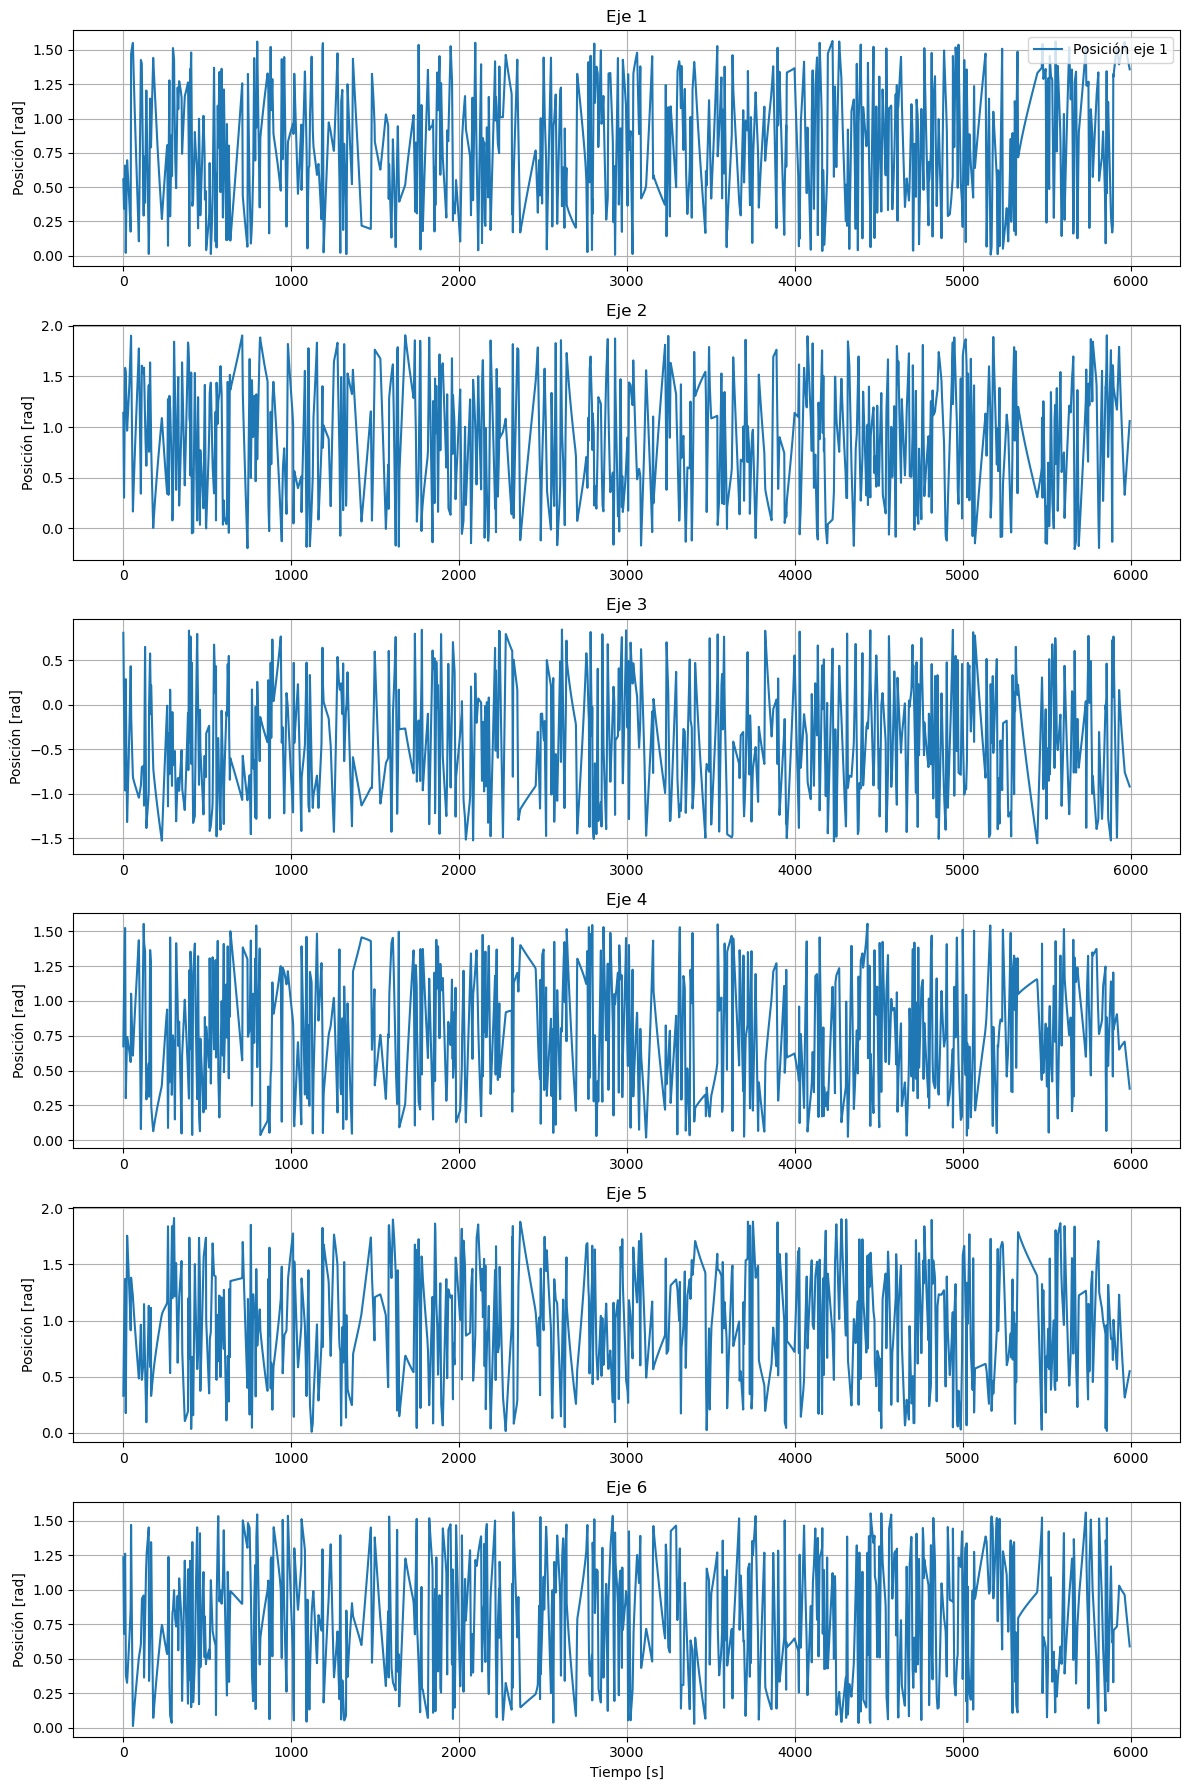

In [10]:
num_links = 6
plt.figure(figsize=(12, 18))
for i in range(num_links):
    plt.subplot(num_links, 1, i+1)
    plt.plot(time_joint, pos_j1 if i == 0 else
                        pos_j2 if i == 1 else
                        pos_j3 if i == 2 else
                        pos_j4 if i == 3 else
                        pos_j5 if i == 4 else
                        pos_j6, label=f'Posición eje {i+1}')
    plt.ylabel('Posición [rad]')
    plt.title(f'Eje {i+1}')
    plt.grid(True)
    #plt.xlim([1998, 2200])
    if i == 0:
        plt.legend(loc='upper right', fontsize=10)
plt.xlabel('Tiempo [s]')
plt.tight_layout() 
plt.show()

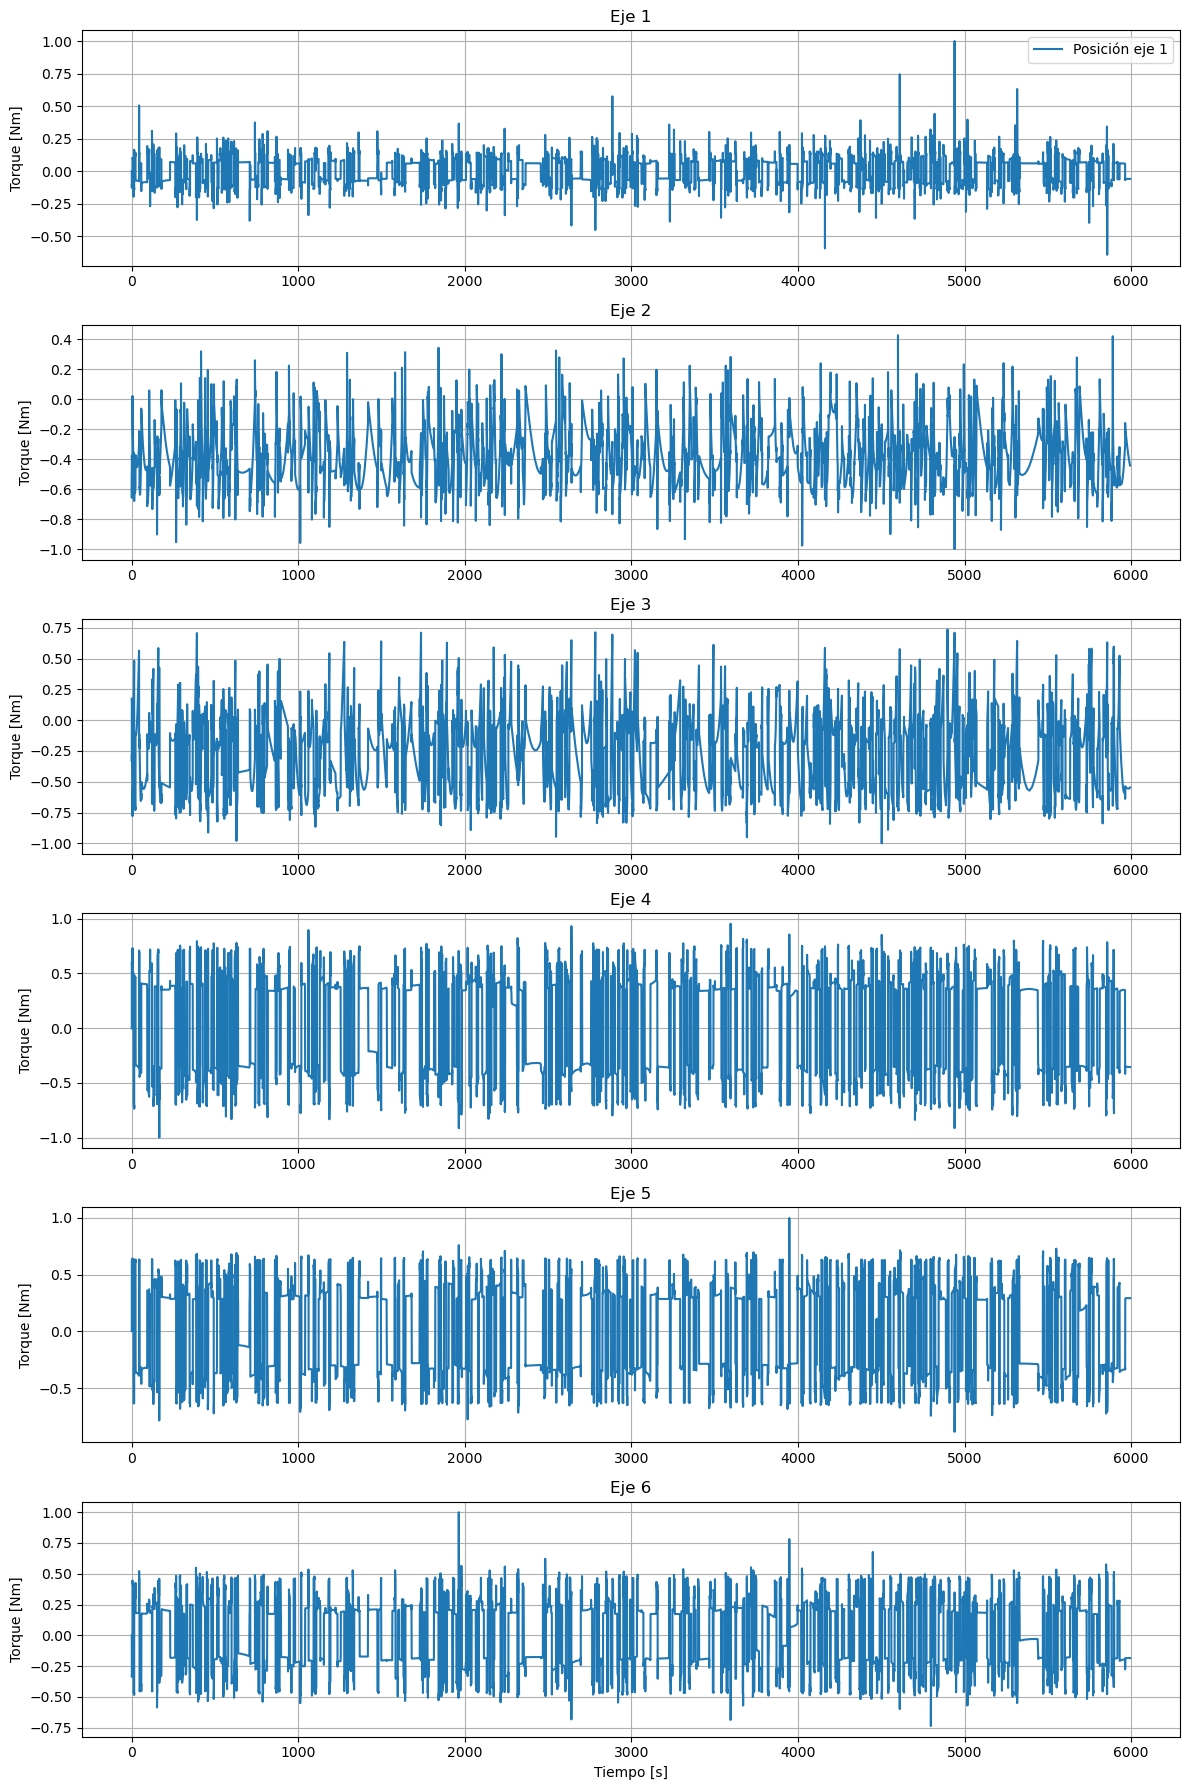

In [11]:
num_links = 6
plt.figure(figsize=(12, 18))
for i in range(num_links):
    plt.subplot(num_links, 1, i+1)
    plt.plot(time_joint, torq_j1 if i == 0 else
                        torq_j2 if i == 1 else
                        torq_j3 if i == 2 else
                        torq_j4 if i == 3 else
                        torq_j5 if i == 4 else
                        torq_j6, label=f'Posición eje {i+1}')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Eje {i+1}')
    plt.grid(True)
    #plt.xlim([1998, 2200])
    if i == 0:
        plt.legend(loc='upper right', fontsize=10)
plt.xlabel('Tiempo [s]')
plt.tight_layout() 
plt.show()

In [12]:
#inputs = np.vstack((pos_j1, pos_j2, pos_j3, pos_j4, pos_j5, pos_j6, vels_j1, vels_j2, vels_j3, vels_j4, vels_j5, vels_j6, torq_j1, torq_j2, torq_j3, torq_j4, torq_j5, torq_j6)).T
inputs = np.vstack((pos_j1, pos_j2, pos_j3, pos_j4, pos_j5, pos_j6, torq_j1, torq_j2, torq_j3, torq_j4, torq_j5, torq_j6)).T
#Aca dudo si es mejor calcular todos los outputs de una, o de a uno
#outputs = np.vstack((accs_j1, accs_j2, accs_j3, accs_j4, accs_j5, accs_j6)).T
outputs = np.vstack((pos_next_j1,pos_next_j2,pos_next_j3,pos_next_j4,pos_next_j5,pos_next_j6)).T

In [13]:
inputs.shape

(599363, 12)

In [14]:
outputs.shape

(599363, 6)

# Red neuronal LSTM

In [15]:
#inputs = np.vstack((pos_j1, pos_j2, pos_j3, pos_j4, pos_j5, pos_j6, vels_j1, vels_j2, vels_j3, vels_j4, vels_j5, vels_j6, torq_j1, torq_j2, torq_j3, torq_j4, torq_j5, torq_j6)).T
inputs = np.vstack((pos_j1, pos_j2, pos_j3, pos_j4, pos_j5, pos_j6, torq_j1, torq_j2, torq_j3, torq_j4, torq_j5, torq_j6)).T
#outputs = np.vstack((accs_j1, accs_j2, accs_j3, accs_j4, accs_j5, accs_j6)).T
outputs = np.vstack((pos_next_j1,pos_next_j2,pos_next_j3,pos_next_j4,pos_next_j5,pos_next_j6)).T

In [16]:
def create_lstm_sequences(inputs, outputs, time_joint, window_size=6, split_train=0.7, split_val=0.15):
    """
    Genera secuencias de entrada y salida para una LSTM, dividiendo el dataset en entrenamiento, validación y test.

    Args:
        inputs (np.ndarray): Matriz (N, F_in) de entradas (posiciones, velocidades, aceleraciones).
        outputs (np.ndarray): Matriz (N, F_out) de salidas (torques).
        time_joint (np.ndarray): Vector (N,) de tiempo asociado a los datos.
        window_size (int): Tamaño de la ventana de tiempo para la LSTM.
        split_train (float): Proporción para el conjunto de entrenamiento (ej: 0.7).
        split_val (float): Proporción para validación (ej: 0.15). El resto se usará para test.

    Returns:
        X_train, Y_train: Datos de entrenamiento.
        X_val, Y_val: Datos de validación.
        X_test, Y_test: Datos de prueba.
        t_val, t_test: Tiempos asociados a Y_val y Y_test.
    """
    assert 0 < split_train < 1, "split_train debe estar entre 0 y 1"
    assert 0 <= split_val < 1, "split_val debe estar entre 0 y 1"
    assert split_train + split_val < 1, "La suma split_train + split_val debe ser menor que 1"

    # Construcción de ventanas
    input_sequences = []
    output_sequences = []
    time_targets = []

    for i in range(len(inputs) - window_size):
        input_sequences.append(inputs[i:i + window_size])
        output_sequences.append(outputs[i + window_size])
        time_targets.append(time_joint[i + window_size])

    X = np.array(input_sequences)
    Y = np.array(output_sequences)
    T = np.array(time_targets)

    # Índices de corte
    n_total = len(X)
    idx_train = int(split_train * n_total)
    idx_val = int((split_train + split_val) * n_total)

    # División de datos
    X_train, Y_train = X[:idx_train], Y[:idx_train]
    X_val, Y_val = X[idx_train:idx_val], Y[idx_train:idx_val]
    X_test, Y_test = X[idx_val:], Y[idx_val:]

    t_val = T[idx_train:idx_val]
    t_test = T[idx_val:]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test, t_val, t_test


In [17]:
w_size=20
# Aplicar StandardScaler
scaler1_LSTM = StandardScaler() #MinMaxScaler(feature_range=(-1, 1)) #StandardScaler() #StandardScaler() #StandardScaler()
inputs = scaler1_LSTM.fit_transform(inputs)

scaler2_LSTM = StandardScaler() #MinMaxScaler(feature_range=(-1, 1)) #StandardScaler() #StandardScaler() #StandardScaler()
outputs = scaler2_LSTM.fit_transform(outputs)

X_train_LSTM, y_train_LSTM, X_val_LSTM, y_val_LSTM, X_test_LSTM, y_test_LSTM, t_val_LSTM, t_test_LSTM = create_lstm_sequences(
    inputs, outputs, time_joint,
    window_size=w_size,
    split_train=0.8,
    split_val=0.1
)

In [18]:
inputs.shape

(599363, 12)

In [19]:
print(X_train_LSTM.shape)
print(X_val_LSTM.shape)
print(X_test_LSTM.shape)

(479474, 20, 12)
(59934, 20, 12)
(59935, 20, 12)


In [20]:
import tensorflow as tf
print(tf.__version__)


2.14.1


In [21]:
np.max(X_train_LSTM)

7.906010395722974

In [22]:
print(X_train_LSTM.dtype, y_train_LSTM.dtype)
print(np.nanmean(X_train_LSTM))


float64 float64
-0.014906203247448024


⚙️ Creando nuevo modelo...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60)                17520     
                                                                 
 dense (Dense)               (None, 6)                 366       
                                                                 
Total params: 17886 (139.73 KB)
Trainable params: 17886 (139.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/1000
3746/3746 [==============================] - 35s 9ms/step - loss: 0.0706 - mae: 0.1305 - val_loss: 0.0036 - val_mae: 0.0432
Epoch 2/1000
  16/3746 [..............................] - ETA: 27s - loss: 0.0015 - mae: 0.0266

/opt/conda/envs/Python-RT24.1-CUDA/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3746/3746 [==============================] - 32s 9ms/step - loss: 5.9636e-04 - mae: 0.0163 - val_loss: 6.2699e-04 - val_mae: 0.0173
Epoch 3/1000
3746/3746 [==============================] - 32s 9ms/step - loss: 1.2668e-04 - mae: 0.0075 - val_loss: 1.8784e-04 - val_mae: 0.0094
Epoch 4/1000
3746/3746 [==============================] - 32s 9ms/step - loss: 4.8865e-05 - mae: 0.0046 - val_loss: 9.3045e-05 - val_mae: 0.0066
Epoch 5/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 2.8052e-05 - mae: 0.0035 - val_loss: 5.6225e-05 - val_mae: 0.0050
Epoch 6/1000
3746/3746 [==============================] - 32s 9ms/step - loss: 1.9464e-05 - mae: 0.0029 - val_loss: 4.3662e-05 - val_mae: 0.0044
Epoch 7/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 1.4869e-05 - mae: 0.0026 - val_loss: 3.3810e-05 - val_mae: 0.0039
Epoch 8/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 1.1924e-05 - mae: 0.0023 - val_loss: 2.8646e-05 - val_mae: 0.003

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



3746/3746 [==============================] - 32s 8ms/step - loss: 4.7885e-07 - mae: 4.1439e-04 - val_loss: 2.0403e-06 - val_mae: 9.3259e-04
Epoch 340/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.8994e-07 - mae: 4.2000e-04 - val_loss: 9.0192e-07 - val_mae: 5.9617e-04
Epoch 341/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.8433e-07 - mae: 4.1970e-04 - val_loss: 9.5933e-07 - val_mae: 6.3211e-04
Epoch 343/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.7841e-07 - mae: 4.1332e-04 - val_loss: 8.0002e-07 - val_mae: 5.4633e-04
Epoch 344/1000
3746/3746 [==============================] - 32s 9ms/step - loss: 4.7998e-07 - mae: 4.1260e-04 - val_loss: 9.0690e-07 - val_mae: 5.9954e-04
Epoch 345/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.7958e-07 - mae: 4.1307e-04 - val_loss: 8.7422e-07 - val_mae: 5.8335e-04
Epoch 346/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.88

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



3746/3746 [==============================] - 32s 8ms/step - loss: 4.4202e-07 - mae: 3.9673e-04 - val_loss: 7.0463e-07 - val_mae: 5.0448e-04
Epoch 392/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.4853e-07 - mae: 3.9686e-04 - val_loss: 6.9178e-07 - val_mae: 4.9154e-04
Epoch 393/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.4602e-07 - mae: 3.9847e-04 - val_loss: 7.0634e-07 - val_mae: 5.1032e-04
Epoch 394/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.3291e-07 - mae: 3.8835e-04 - val_loss: 7.5731e-07 - val_mae: 5.4972e-04
Epoch 395/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.5375e-07 - mae: 3.9937e-04 - val_loss: 8.8279e-07 - val_mae: 6.0215e-04
Epoch 396/1000
3746/3746 [==============================] - 32s 9ms/step - loss: 4.3348e-07 - mae: 3.9194e-04 - val_loss: 1.0168e-06 - val_mae: 6.7774e-04
Epoch 397/1000
3746/3746 [==============================] - 32s 8ms/step - loss: 4.44

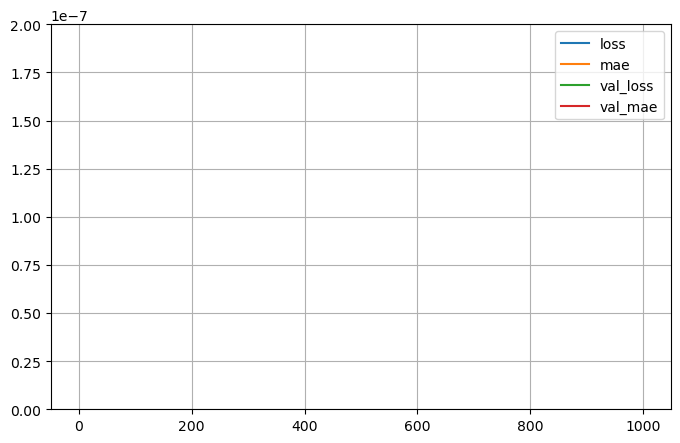

✅ Modelo LSTM listo para usar.


In [23]:
# Verificar si el modelo ya existe

LSTM_model_path = "LSTM_nn_Best_Model.h5"
LSTM_history_path = "lstm_best_history.json"

if os.path.exists(LSTM_model_path):
    print("🔄 Cargando modelo LSTM existente...")
    LSTM_network = keras.models.load_model(LSTM_model_path)
    LSTM_network.summary()

    if os.path.exists(LSTM_history_path):

        with open(LSTM_history_path, "r") as f:
            LSTM_history = json.load(f)  # Load the history data as a dictionary
        # Create a dummy History object for plotting:
        #LSTM_history = type('DummyHistory', (object,), {'history': LSTM_history_dict})()

        # Graficar el history
        plt.figure(figsize=(8, 5))
        plt.plot(LSTM_history["loss"], label="Training Loss")
        plt.plot(LSTM_history["val_loss"], label="Validation Loss")
        plt.legend()
        plt.xlabel("Épocas")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.gca().set_ylim(0, 2e-6)
        plt.title("Historial de entrenamiento del modelo LSTM")
        plt.show()
    else:
        print("⚠️ No se encontró el archivo de history.")
else:
    print("⚙️ Creando nuevo modelo...")
    LSTM_network = Sequential() #Sequential([Input(shape=(w_size, X_train_LSTM.shape[2]))])
    LSTM_network.add(LSTM(60, activation='tanh', input_shape=(w_size, X_train_LSTM.shape[2])))
    
    #LSTM_network.add(LSTM(60, activation='tanh', input_shape=(w_size, X_train_LSTM.shape[2]), return_sequences=True))
    #LSTM_network.add(LSTM(100, activation='tanh',return_sequences=True))
    #LSTM_network.add(LSTM(6, activation='tanh'))
    LSTM_network.add(Dense(y_train_LSTM.shape[1]))
    LSTM_network.compile(loss = 'mean_squared_error', optimizer=keras.optimizers.Adam(1e-4), metrics = ['mae']) #learning_rate=1e-5
    #mean_sqared_error
    LSTM_network.summary()


    #LSTM_checkpoint_cb = keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/CT_p/Modelos_NN/LINEAR/LSTM_nn_Best_Model.h5", save_best_only=True)
    LSTM_checkpoint_cb = keras.callbacks.ModelCheckpoint(LSTM_model_path, save_best_only=True)
    LSTM_early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                           patience=80, min_delta=1E-10, 
                                                           restore_best_weights=True)
    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',     # Qué métrica mirar
            factor=0.5,             # Multiplica LR por este factor (0.5 = divide a la mitad)
            patience=50,            # Nº de épocas sin mejora antes de reducir
            min_lr=1e-10,            # LR mínimo permitido
            verbose=1               # Imprime mensaje cuando reduce
        )

    LSTM_history = LSTM_network.fit(X_train_LSTM, y_train_LSTM, epochs=1000, 
                                    batch_size=128, validation_data=(X_val_LSTM, y_val_LSTM), 
                                    callbacks=[LSTM_checkpoint_cb, LSTM_early_stopping_cb])

    #LSTM_network.save("LSTM_nn_Best_Model.keras", save_best_only=True)
    
    with open(LSTM_history_path, "w") as f:
        json.dump(LSTM_history.history, f)
    with open(LSTM_history_path, "r") as f:
        LSTM_history = json.load(f)  # Load the history data as a dictionary

    # Create a dummy History object for plotting:
    #LSTM_history = type('DummyHistory', (object,), {'history': LSTM_history_dict})()

    pd.DataFrame(LSTM_history).plot(figsize=(8, 5))
    plt.grid(True)
    #plt.gca().set_xlim(0, 1)
    plt.gca().set_ylim(0, 2e-7)
    plt.show()

print("✅ Modelo LSTM listo para usar.")

In [24]:
LSTM_accuracy_test = LSTM_network.evaluate(X_test_LSTM, y_test_LSTM)

1873/1873 [==============================] - 10s 5ms/step - loss: 3.2777e-07 - mae: 3.4767e-04


In [25]:
LSTM_predictions = LSTM_network.predict(X_test_LSTM)

1873/1873 [==============================] - 8s 4ms/step


In [26]:
LSTM_predictions[0]

array([ 0.75012263, -0.44016916, -0.79413628,  0.90771013,  1.32465577,
        0.31462718])

In [ ]:
y_test_LSTM[0]

array([ 0.75011213, -0.43987522, -0.79436641,  0.9083023 ,  1.32524456,
        0.31430877])

*   [tf.keras.layers.LSTM](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM)



In [ ]:
!ls -lh LSTM_nn_Best_Model.h5 lstm_best_history.json


-rw-rw---- 1 wsuser wscommon  91K Jul 16 21:05 lstm_best_history.json
-rw-rw---- 1 wsuser wscommon 449K Jul 16 20:58 LSTM_nn_Best_Model.h5


In [ ]:
from IPython.display import FileLink

# Crear enlaces para descarga
FileLink('LSTM_nn_Best_Model.h5')


/home/wsuser/work/LSTM_nn_Best_Model.h5

In [ ]:
FileLink('lstm_best_history.json')


/home/wsuser/work/lstm_best_history.json

In [ ]:
#import os
#os.remove("LSTM_nn_Best_Model.h5")
#os.remove("lstm_best_history.json")


# Verificación de métricas y validación con nuevo dataset

In [ ]:
#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
time_joint_N= times['Output_NN_NN_New_2_time'][0:-2]

pos_j1_N = j_poses['Output_NN_NN_New_2_pos_j1'][0:-2]  #34440 -> 34438, k
pos_j2_N = j_poses['Output_NN_NN_New_2_pos_j2'][0:-2]
pos_j3_N = j_poses['Output_NN_NN_New_2_pos_j3'][0:-2] 
pos_j4_N = j_poses['Output_NN_NN_New_2_pos_j4'][0:-2] 
pos_j5_N = j_poses['Output_NN_NN_New_2_pos_j5'][0:-2] 
pos_j6_N = j_poses['Output_NN_NN_New_2_pos_j6'][0:-2] 

vels_j1_N = j_vels['Output_NN_NN_New_2_vel_j1'][1:-1]  #34440 -> 34438 k
vels_j2_N = j_vels['Output_NN_NN_New_2_vel_j2'][1:-1] 
vels_j3_N = j_vels['Output_NN_NN_New_2_vel_j3'][1:-1] 
vels_j4_N = j_vels['Output_NN_NN_New_2_vel_j4'][1:-1] 
vels_j5_N = j_vels['Output_NN_NN_New_2_vel_j5'][1:-1] 
vels_j6_N = j_vels['Output_NN_NN_New_2_vel_j6'][1:-1] 

torq_j1_N = j_torqs['Output_NN_NN_New_2_torq_j1'][1:-1]  #34440 -> 34438 k
torq_j2_N = j_torqs['Output_NN_NN_New_2_torq_j2'][1:-1] 
torq_j3_N = j_torqs['Output_NN_NN_New_2_torq_j3'][1:-1] 
torq_j4_N = j_torqs['Output_NN_NN_New_2_torq_j4'][1:-1] 
torq_j5_N = j_torqs['Output_NN_NN_New_2_torq_j5'][1:-1] 
torq_j6_N = j_torqs['Output_NN_NN_New_2_torq_j6'][1:-1] 

#Outputs
accs_j1_N = j_accels['Output_NN_NN_New_2_acc_j1']  #34438 k
accs_j2_N = j_accels['Output_NN_NN_New_2_acc_j2'] 
accs_j3_N = j_accels['Output_NN_NN_New_2_acc_j3'] 
accs_j4_N = j_accels['Output_NN_NN_New_2_acc_j4'] 
accs_j5_N = j_accels['Output_NN_NN_New_2_acc_j5'] 
accs_j6_N = j_accels['Output_NN_NN_New_2_acc_j6'] 


pos_next_j1_N = j_poses['Output_NN_NN_New_2_pos_j1'][1:-1]  #34440 -> 34438, k
pos_next_j2_N = j_poses['Output_NN_NN_New_2_pos_j2'][1:-1] 
pos_next_j3_N = j_poses['Output_NN_NN_New_2_pos_j3'][1:-1] 
pos_next_j4_N = j_poses['Output_NN_NN_New_2_pos_j4'][1:-1] 
pos_next_j5_N = j_poses['Output_NN_NN_New_2_pos_j5'][1:-1] 
pos_next_j6_N = j_poses['Output_NN_NN_New_2_pos_j6'][1:-1] 

In [ ]:
inputs_NEW = np.vstack((pos_j1_N, pos_j2_N, pos_j3_N, pos_j4_N, pos_j5_N, pos_j6_N, torq_j1_N, torq_j2_N, torq_j3_N, torq_j4_N, torq_j5_N, torq_j6_N)).T
outputs_NEW = np.vstack((pos_next_j1_N,pos_next_j2_N,pos_next_j3_N,pos_next_j4_N,pos_next_j5_N,pos_next_j6_N)).T

In [ ]:
def create_sequences_with_time(data, time, window_size= w_size):
    sequences = []
    times = []
    
    for i in range(len(data) - window_size + 1):
        sequence = data[i:i + window_size]
        sequences.append(sequence)
        
        # Obtener el tiempo correspondiente al centro de la ventana
        time_center = time[i + window_size -1]  # Usa el centro de la ventana
        times.append(time_center)
    
    return np.array(sequences), np.array(times)

X_test_scaled_LSTM = scaler1_LSTM.transform(inputs_NEW)
X_test_windowed_LSTM, t_ref_LSTM = create_sequences_with_time(X_test_scaled_LSTM, time_joint_N)
q_sim_LSTM = scaler2_LSTM.inverse_transform(LSTM_network.predict(X_test_windowed_LSTM))

21796/21796 [==============================] - 95s 4ms/step


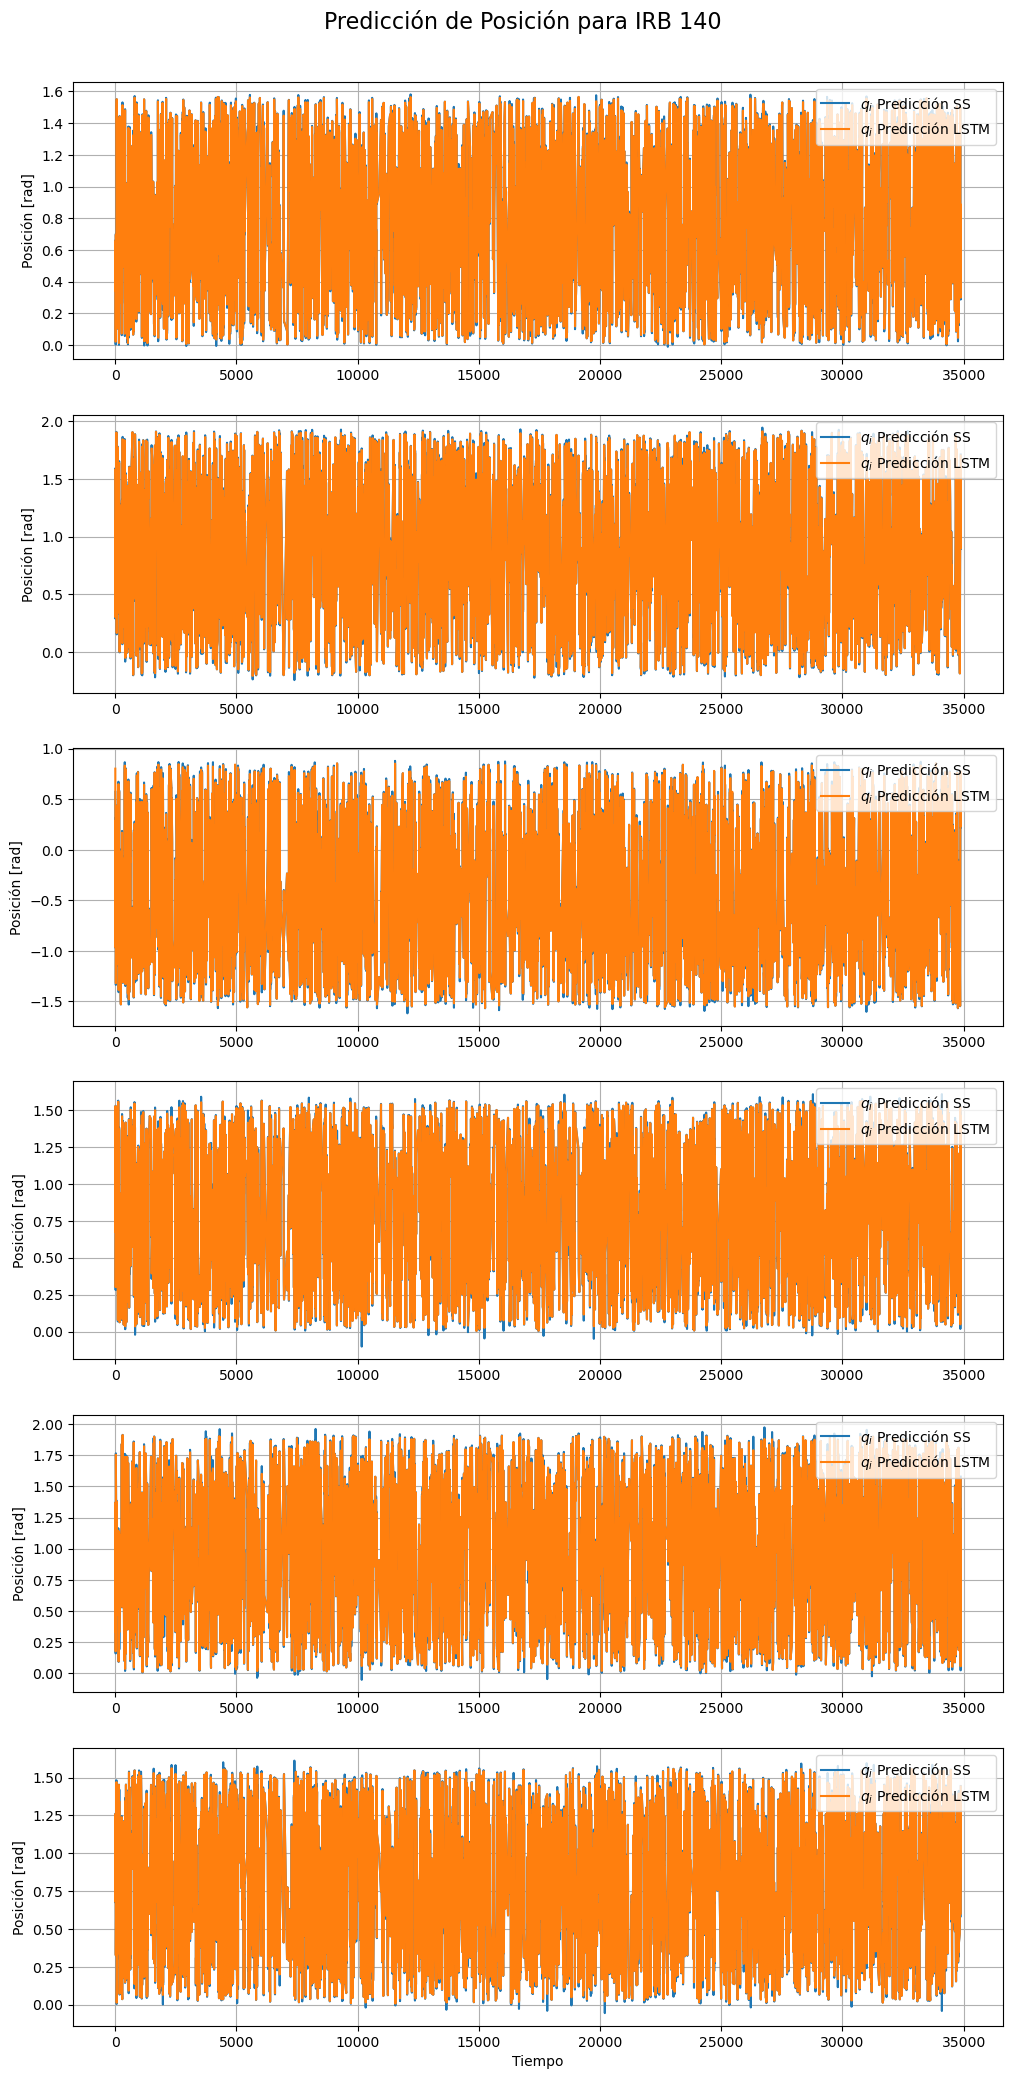

In [ ]:
num_links = 6
t_ref = time_joint
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 24))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Predicción de Posición para IRB 140", fontsize=16, y=0.95)

# Grafico los resultados
for i in range(num_links):
  plt.subplot(num_links, 1, i+1)
  plt.plot(t_ref_LSTM,q_sim_LSTM[:,i])
  plt.plot(time_joint_N,outputs_NEW[:,i])
  plt.ylabel('Posición [rad]')
  plt.legend([r"$q_{i}$ Predicción SS", r"$q_{i}$ Predicción LSTM", r"$q_{i}$ " f'Eje {i+1}'],loc='upper right', 
             fontsize=10)
  plt.grid(True)

plt.subplots_adjust(top=0.92)  
plt.xlabel('Tiempo');
plt.show()

Eje 1:
LSTM - MAE: 2.498259e-03, MSE: 1.548326e-05, R²: 0.9998880665
Eje 2:
LSTM - MAE: 3.111357e-03, MSE: 2.401621e-05, R²: 0.9999027430
Eje 3:
LSTM - MAE: 3.582613e-03, MSE: 3.478988e-05, R²: 0.9998776882
Eje 4:
LSTM - MAE: 2.499958e-03, MSE: 2.283238e-05, R²: 0.9998397569
Eje 5:
LSTM - MAE: 3.039600e-03, MSE: 3.232741e-05, R²: 0.9998414575
Eje 6:
LSTM - MAE: 2.496272e-03, MSE: 2.332959e-05, R²: 0.9998357709


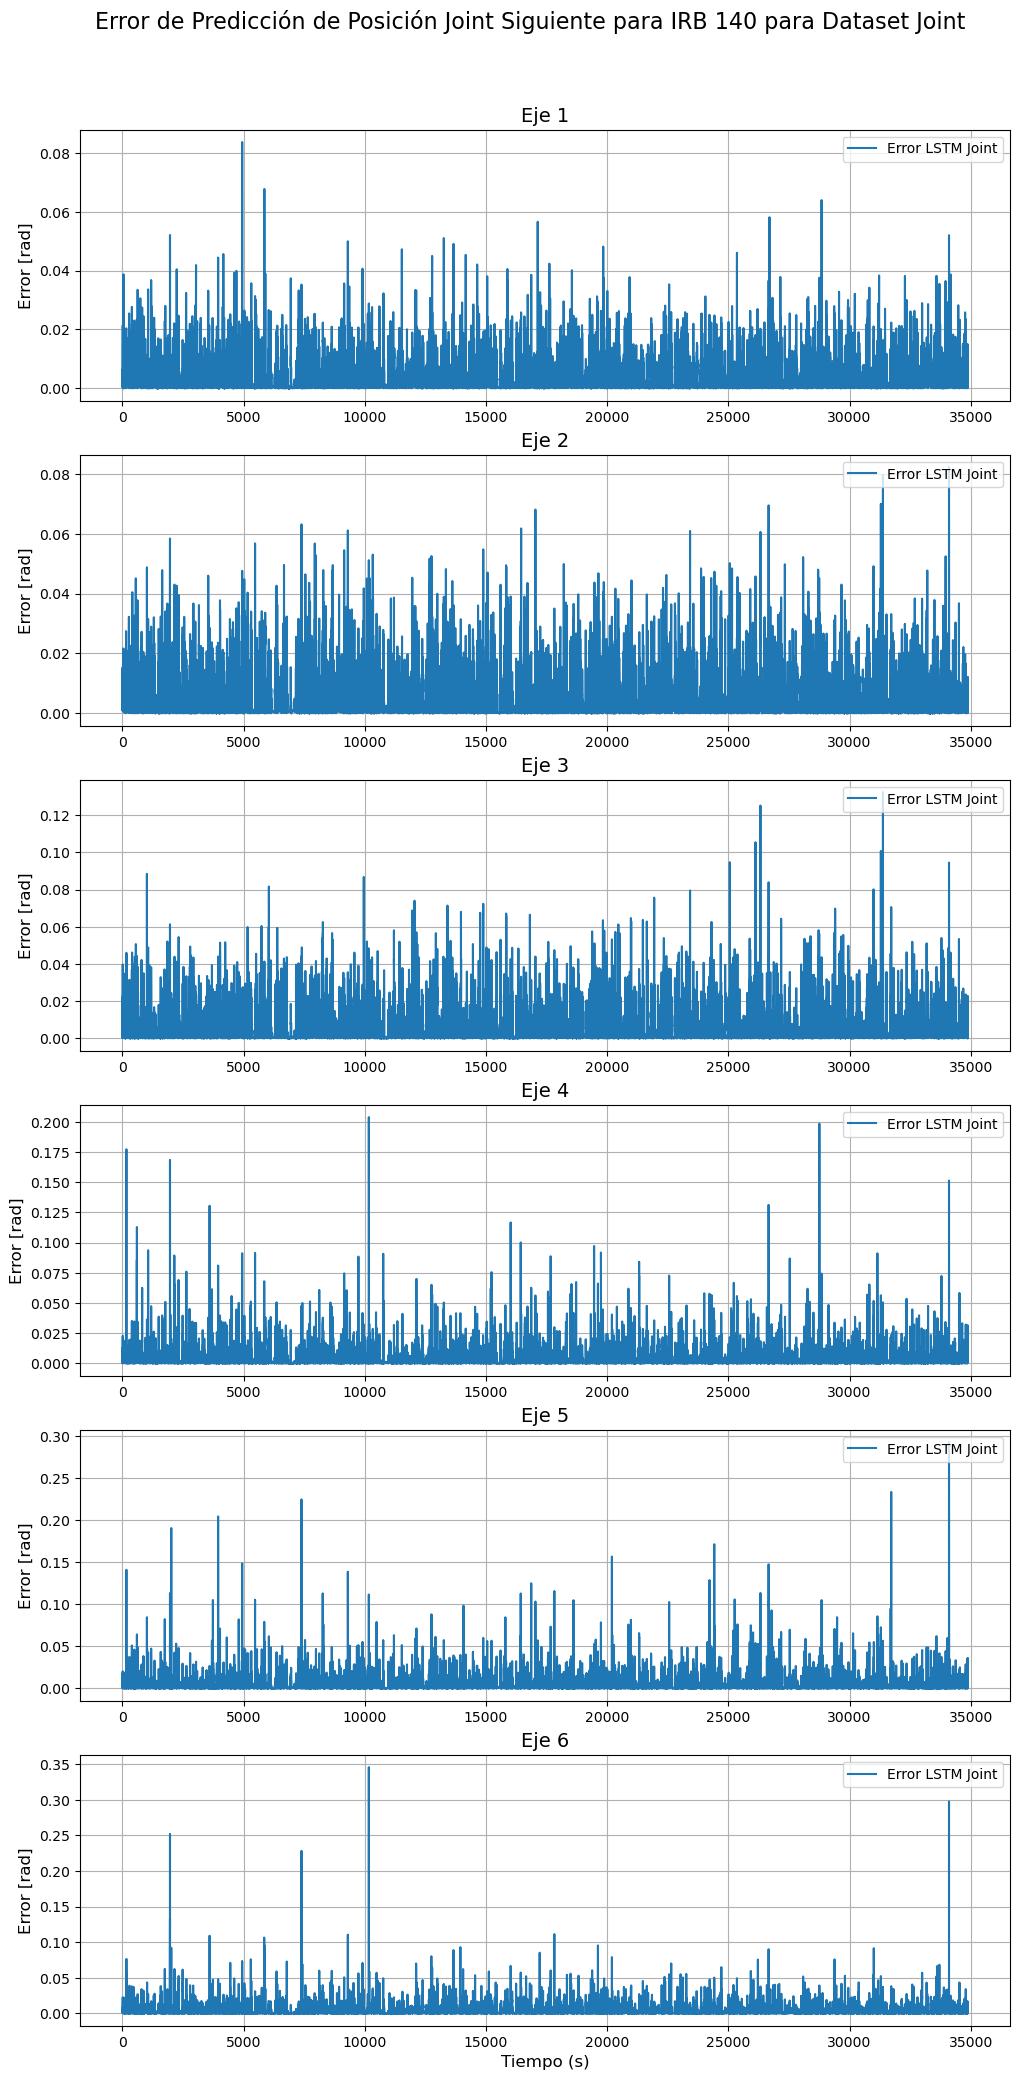

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 24))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error de Predicción de Posición Joint Siguiente para IRB 140 para Dataset Joint", 
             fontsize=16,  y=0.95)

# Graficar los errores
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)
    y_true = outputs_NEW[:, i]             # Señal real 
    y_pred_lstm = q_sim_LSTM[:, i]         # Predicción LSTM

    # MAE
    mae_lstm = mean_absolute_error(y_true[w_size-1:], y_pred_lstm)

    # MSE
    mse_lstm = mean_squared_error(y_true[w_size-1:], y_pred_lstm)

    # R²
    r2_lstm = r2_score(y_true[w_size-1:], y_pred_lstm)

    # Imprimir resultados
    print(f"Eje {i+1}:")
    print(f"LSTM - MAE: {mae_lstm:.6e}, MSE: {mse_lstm:.6e}, R²: {r2_lstm:.10f}")

    error_LSTM_Joint_j = np.sqrt((q_sim_LSTM[:, i] - outputs_NEW[w_size-1:, i])**2)
    
    # Graficar los errores
    plt.plot(t_ref_LSTM, error_LSTM_Joint_j, label='Error LSTM Joint')
    
    # Ajustar etiquetas y título del subplot
    plt.ylabel(r'Error [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

plt.subplots_adjust(top=0.90)  

# Ajustar los espacios entre subplots
#plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()


# Verificación con Dataset Lineal

In [ ]:
#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
time_joint_l= times['Output_linear_002_test_NN_NN_time'][0:-2]

pos_j1_l = j_poses['Output_linear_002_test_NN_NN_pos_j1'][0:-2] #34440 -> 34438, k-1
pos_j2_l = j_poses['Output_linear_002_test_NN_NN_pos_j2'][0:-2]
pos_j3_l = j_poses['Output_linear_002_test_NN_NN_pos_j3'][0:-2]
pos_j4_l = j_poses['Output_linear_002_test_NN_NN_pos_j4'][0:-2]
pos_j5_l = j_poses['Output_linear_002_test_NN_NN_pos_j5'][0:-2]
pos_j6_l = j_poses['Output_linear_002_test_NN_NN_pos_j6'][0:-2]

vels_j1_l = j_vels['Output_linear_002_test_NN_NN_vel_j1'][0:-2] #34440 -> 34438 k-1
vels_j2_l = j_vels['Output_linear_002_test_NN_NN_vel_j2'][0:-2]
vels_j3_l = j_vels['Output_linear_002_test_NN_NN_vel_j3'][0:-2]
vels_j4_l = j_vels['Output_linear_002_test_NN_NN_vel_j4'][0:-2]
vels_j5_l = j_vels['Output_linear_002_test_NN_NN_vel_j5'][0:-2]
vels_j6_l = j_vels['Output_linear_002_test_NN_NN_vel_j6'][0:-2]

torq_j1_l = j_torqs['Output_linear_002_test_NN_NN_torq_j1'][1:-1] #34440 -> 34438 k
torq_j2_l = j_torqs['Output_linear_002_test_NN_NN_torq_j2'][1:-1]
torq_j3_l = j_torqs['Output_linear_002_test_NN_NN_torq_j3'][1:-1]
torq_j4_l = j_torqs['Output_linear_002_test_NN_NN_torq_j4'][1:-1]
torq_j5_l = j_torqs['Output_linear_002_test_NN_NN_torq_j5'][1:-1]
torq_j6_l = j_torqs['Output_linear_002_test_NN_NN_torq_j6'][1:-1]

#Outputs
accs_j1_l = j_accels['Output_linear_002_test_NN_NN_acc_j1'] #34438 k
accs_j2_l = j_accels['Output_linear_002_test_NN_NN_acc_j2']
accs_j3_l = j_accels['Output_linear_002_test_NN_NN_acc_j3']
accs_j4_l = j_accels['Output_linear_002_test_NN_NN_acc_j4']
accs_j5_l = j_accels['Output_linear_002_test_NN_NN_acc_j5']
accs_j6_l = j_accels['Output_linear_002_test_NN_NN_acc_j6']

#Inputs ---> uk=[qTk-1  d_qTk-1  tauTk]T
pos_next_j1_l = j_poses['Output_linear_002_test_NN_NN_pos_j1'][1:-1] #34440 -> 34438, k-1
pos_next_j2_l = j_poses['Output_linear_002_test_NN_NN_pos_j2'][1:-1]
pos_next_j3_l = j_poses['Output_linear_002_test_NN_NN_pos_j3'][1:-1]
pos_next_j4_l = j_poses['Output_linear_002_test_NN_NN_pos_j4'][1:-1]
pos_next_j5_l = j_poses['Output_linear_002_test_NN_NN_pos_j5'][1:-1]
pos_next_j6_l = j_poses['Output_linear_002_test_NN_NN_pos_j6'][1:-1]

KeyError: 'Output_linear_002_test_NN_NN_time'

In [ ]:
inputs_lin = np.vstack((pos_j1_l, pos_j2_l, pos_j3_l, pos_j4_l, pos_j5_l, pos_j6_l, torq_j1_l, torq_j2_l, torq_j3_l, torq_j4_l, torq_j5_l, torq_j6_l)).T
outputs_lin = np.vstack((pos_next_j1_l,pos_next_j2_l,pos_next_j3_l,pos_next_j4_l,pos_next_j5_l,pos_next_j6_l)).T

In [ ]:
X_test_scaled_LSTM_L = scaler1_LSTM.transform(inputs_lin)
X_test_windowed_LSTM_L, t_ref_LSTM_L = create_sequences_with_time(X_test_scaled_LSTM_L, time_joint_l)
q_sim_LSTM_L = scaler2_LSTM.inverse_transform(LSTM_network.predict(X_test_windowed_LSTM_L))

In [ ]:
num_links = 6

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 24))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Predicción de Posición para IRB 140 con Dataset Cartesiano", fontsize=16, y=0.95)

# Grafico los resultados
for i in range(num_links):
  plt.subplot(num_links, 1, i+1)
  plt.plot(t_ref_LSTM_L,q_sim_LSTM_L[:,i])
  plt.plot( time_joint_l,outputs_lin[:,i])
  plt.ylabel('Posición [rad]')
  plt.legend([r"$q_{i}$ Predicción SS", r"$q_{i}$ Predicción LSTM", r"$q_{i}$ " f'Eje {i+1}'],loc='upper right', 
             fontsize=10)
  plt.grid(True)

plt.subplots_adjust(top=0.92)  
plt.xlabel('Tiempo');
plt.show()

In [ ]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 24))  # Cambia el tamaño según tus necesidades

# Agregar un título general
plt.suptitle("Error de Predicción de Posición Joint Siguiente para IRB 140 para Dataset Cartesiano", 
             fontsize=16,  y=0.95)

# Graficar los errores
for i in range(num_links):
    plt.subplot(num_links, 1, i + 1)

    error_LSTM_Joint_L = np.sqrt((q_sim_LSTM_L[:, i] - outputs_lin[w_size-1:, i])**2)
    
    # Graficar los errores
    plt.plot(t_ref_LSTM_L, error_LSTM_Joint_L, label='Error LSTM Joint')
    
    # Ajustar etiquetas y título del subplot
    plt.ylabel(r'Error [rad]', fontsize=12)
    plt.title(f'Eje {i+1}', fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)  # Añadir una cuadrícula para facilitar la lectura

# Etiqueta para el eje X
plt.xlabel('Tiempo (s)', fontsize=12)

plt.subplots_adjust(top=0.90)  

# Ajustar los espacios entre subplots
#plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título general

# Mostrar el gráfico
plt.show()


In [ ]:
import project_lib
project = project_lib.Project()
project.save_data("LSTM_model_best.h5", open("LSTM_model_best.h5", "rb"))
project.save_data("lstm_best_history.json", open("lstm_best_history.json", "rb"))

# **PROBLEMA DINÁMICO INVERSO**

# Red Feed-Forward

# Verificación de métricas y validación con nuevo dataset

# Verificación con Dataset Lineal

# **SECUENCIA CONTROLADOR-SIMULADOR**

# Controlador

# Reconstrucción de Velocidad y Aceleración

# Simulador